In [1]:
!pip install torch torchvision --quiet
!pip install numpy matplotlib --quiet
!pip install requests --quiet

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import math
import os
import time
import random
from torch.optim import AdamW

In [4]:
import urllib.request
url = "https://www.gutenberg.org/cache/epub/6099/pg6099.txt"
urllib.request.urlretrieve(url, "poems_raw.txt")
print("Downloaded!")

Downloaded!


In [5]:
with open("poems_raw.txt", "r", encoding="utf-8") as f:
    text = f.read()

start = text.find("LES FLEURS DU MAL")
end = text.find("End of the Project Gutenberg")
text = text[start:end].strip()
base_text = text
target_size = 1_200_000

if len(base_text) < target_size:
    multiplier = math.ceil(target_size / len(base_text))
    text = ((base_text + "\n\n") * multiplier)[:target_size]
else:
    text = base_text

print("Corpus expanded for training-size suitability")

print(f"Corpus size: {len(text)} characters")

Corpus expanded for training-size suitability
Corpus size: 1200000 characters


In [6]:
print(text[:500])

LES FLEURS DU MAL ***




Produced by Tonya Allen, Julie Barkley, Juliet Sutherland,
Charles Franks and the Online Distributed Proofreading Team.












LES FLEURS DU MAL

par

CHARLES BAUDELAIRE

_Préface par Henry FRICHET_





[Illustration]

PRÉFACE


Charles Baudelaire avait un ami, Auguste Poulet-Malassis, ancien élève
de l'école des Chartes, qui s'était fait éditeur par goût pour les
raffinements typographiques et pour la littérature qu'il jugeait en
érudit et en artiste beaucoup plu


In [7]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size} characters")
print("Characters:", ''.join(chars[:30]), "...")

Vocabulary size: 107 characters
Characters: 
 !#$%'()*+,-./0123456789:;?AB ...


In [8]:
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s if c in stoi]
decode = lambda l: ''.join([itos[i] for i in l])

In [9]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"Train: {len(train_data)} | Val: {len(val_data)}")

Train: 1080000 | Val: 120000


In [10]:
def get_batch(split, block_size=256, batch_size=32):
    source = train_data if split == "train" else val_data
    ix = torch.randint(len(source) - block_size, (batch_size,))
    x = torch.stack([source[i:i+block_size] for i in ix])
    y = torch.stack([source[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [12]:
BLOCK_SIZE = 256
BLOCK_SIZE_SMALL = 128
N_LAYERS = 6
N_HEADS = 8
N_EMBED = 256
DROPOUT = 0.2
BATCH_SIZE = 32
LR = 3e-4

In [13]:
USE_FLASH_ATTENTION = True

In [14]:
class CausalSelfAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.qkv = nn.Linear(N_EMBED, 3 * N_EMBED, bias=False)
        self.proj = nn.Linear(N_EMBED, N_EMBED)
        self.drop = nn.Dropout(DROPOUT)
    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(N_EMBED, dim=2)
        q = q.view(B, T, N_HEADS, C // N_HEADS).transpose(1, 2)
        k = k.view(B, T, N_HEADS, C // N_HEADS).transpose(1, 2)
        v = v.view(B, T, N_HEADS, C // N_HEADS).transpose(1, 2)
        if USE_FLASH_ATTENTION:
            y = F.scaled_dot_product_attention(
                q,
                k,
                v,
                is_causal=True,
                dropout_p=DROPOUT if self.training else 0
            )
        else:
            mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)
            att = (q @ k.transpose(-2, -1)) / math.sqrt(k.size(-1))
            att = att.masked_fill(mask == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)

        return self.proj(y)

In [15]:
class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(N_EMBED, 4 * N_EMBED),
            nn.GELU(),
            nn.Linear(4 * N_EMBED, N_EMBED),
            nn.Dropout(DROPOUT))
    def forward(self, x): return self.net(x)

In [16]:
class TransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.attn = CausalSelfAttention()
        self.ff   = FeedForward()
        self.ln1  = nn.LayerNorm(N_EMBED)
        self.ln2  = nn.LayerNorm(N_EMBED)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        return x + self.ff(self.ln2(x))

In [17]:
class PoetryGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, N_EMBED)
        self.pos_emb = nn.Embedding(BLOCK_SIZE, N_EMBED)
        self.blocks  = nn.Sequential(*[TransformerBlock() for _ in range(N_LAYERS)])
        self.ln_f    = nn.LayerNorm(N_EMBED)
        self.head    = nn.Linear(N_EMBED, vocab_size, bias=False)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.tok_emb(idx)
        pos = self.pos_emb(torch.arange(T, device=device))
        x   = self.blocks(self.ln_f(tok + pos))
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))
        return logits, loss

In [18]:
model = PoetryGPT().to(device)
print("Positional embedding: learned")
n_params = sum(p.numel() for p in model.parameters())
print(f"Model has {n_params/1e6:.2f}M parameters")

Positional embedding: learned
Model has 4.85M parameters


In [19]:
@torch.no_grad()
def estimate_loss(eval_iters=100):
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = [model(*get_batch(split))[1].item() for _ in range(eval_iters)]
        out[split] = np.mean(losses)
    model.train()
    return out

In [20]:
@torch.no_grad()
def generate(prompt="\n", max_new_tokens=300, temperature=0.8):
    model.eval()
    tokens = encode(prompt) if prompt else encode("\n")
    if len(tokens) == 0:
        tokens = [0]  # fallback: use first token in vocab
    idx = torch.tensor([tokens], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -BLOCK_SIZE:]
        logits, _ = model(idx_cond)
        probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)
    model.train()
    return decode(idx[0].tolist())

In [21]:
optimizer = AdamW(model.parameters(), lr=LR)
train_losses, val_losses, steps_log = [], [], []
TOTAL_STEPS = 10000
EVAL_EVERY  = 500
GEN_EVERY   = 2000

In [22]:
print("Starting training... (this will take a while, grab a coffee..)")
for step in range(TOTAL_STEPS):
    xb, yb = get_batch("train")
    _, loss = model(xb, yb)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    if step % EVAL_EVERY == 0:
        ev = estimate_loss()
        train_losses.append(ev["train"]); val_losses.append(ev["val"])
        steps_log.append(step)
        bpc = ev["val"] / math.log(2)
        print(f"Step {step:5d} | train={ev['train']:.3f} | val={ev['val']:.3f} | bpc={bpc:.3f}")
    if step % GEN_EVERY == 0 and step > 0:
        print("\n--- Sample ---\n", generate()[:200], "\n---\n")

Starting training... (this will take a while, grab a coffee..)
Step     0 | train=3.988 | val=3.960 | bpc=5.713
Step   500 | train=2.121 | val=2.073 | bpc=2.991
Step  1000 | train=1.764 | val=1.731 | bpc=2.497
Step  1500 | train=1.528 | val=1.518 | bpc=2.190
Step  2000 | train=1.338 | val=1.349 | bpc=1.946

--- Sample ---
 
  De couleur vers un range épar l'homme resse,
  De celaient les fragages gassés de loisants,
  Qui dans le sangle et sourir, et je mais aimer,
  Et les espris frois espides,

  Se profondit le ma cr 
---

Step  2500 | train=1.160 | val=1.182 | bpc=1.705
Step  3000 | train=0.967 | val=0.997 | bpc=1.438
Step  3500 | train=0.772 | val=0.819 | bpc=1.182
Step  4000 | train=0.571 | val=0.618 | bpc=0.892

--- Sample ---
 
  Certigne à ce quelque vieux chaîte,
  La tête sur le trais d'amour,
  Et qui le soleil au min de sang.

  Vois chaque jour l'espace effroi:
  --Mais je ne ferai pas le forte à la calme;
  O mon sei 
---

Step  4500 | train=0.416 | val=0.460 | bpc=0.664

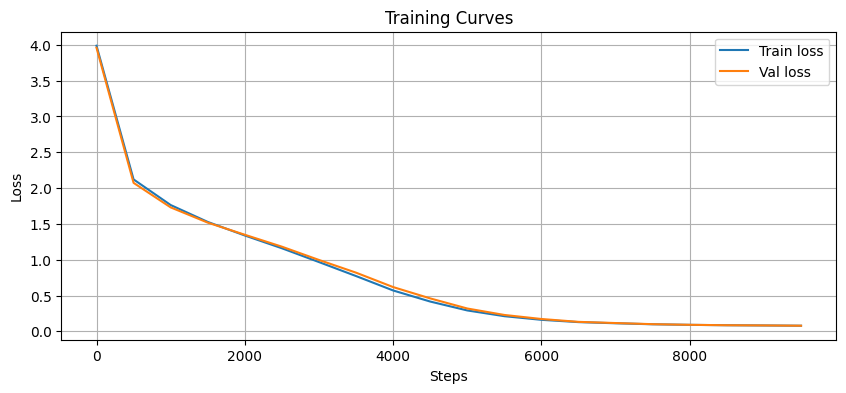

In [23]:
plt.figure(figsize=(10,4))
plt.plot(steps_log, train_losses, label="Train loss")
plt.plot(steps_log, val_losses,   label="Val loss")
plt.xlabel("Steps"); plt.ylabel("Loss")
plt.title("Training Curves"); plt.legend(); plt.grid(True)
plt.savefig("training_curves.png", dpi=150); plt.show()

In [24]:
torch.save({
    "model_state": model.state_dict(),
    "vocab_size": vocab_size,
    "stoi": stoi, "itos": itos,
    "train_losses": train_losses,
    "val_losses": val_losses,
}, "poetry_gpt_checkpoint.pt")
print("Model saved!")

Model saved!


In [25]:
print("=== GENERATED POEM 1 (temperature=0.7) ===")
print(generate(temperature=0.7, max_new_tokens=400))

=== GENERATED POEM 1 (temperature=0.7) ===

  Le feu clarté des languissantes et des bois!

  Car j'eusse nore âme tresse
  A travers le chaos de vermie
  Le ciel déjà la flamme étaler,
  Ainsi qu'un vivant, donnement une musc qui se brouge,
  Ton coeur s'allume et d'un vague épouvante,
  Où se pieds le plafond d'un souffle vague,
         Vivain de son bâton;
  Plus ton coeur la titrès belle
  Qui fait ma joie et ma santé,
  Salut en immor


In [26]:
print("=== GENERATED POEM 2 (temperature=1.0) ===")
print(generate(temperature=1.0, max_new_tokens=400))

=== GENERATED POEM 2 (temperature=1.0) ===

  Plutôt que de nourrir cette dérision!
  Maudite soit la pauvre extase vide,
  Où se pertister ma plaie auvre homme une grandeur,

  Qui te car je ne serai plus qu'un foetus rêve!
  Je puis à me Dis: « Comme, j'ai trouvé de tous grande,
  C'est voyage un viétur d'un porter au moins
  D'un linceul vaporeux et d'un vague tombeau.

  Dans cette grande plaine où l'autan froid se joue,
  Où par les lo


In [27]:
prompt = text[100:150]
print("Prompt:", repr(prompt))
print("\n=== GENERATED CONTINUATION ===")
print(generate(prompt=prompt, temperature=0.8, max_new_tokens=300))

Prompt: 'and the Online Distributed Proofreading Team.\n\n\n\n\n'

=== GENERATED CONTINUATION ===
and the Online Distributed Proofreading Team.










  LE CHATIMER DE LA DOULEUR


  L'un t'éclaire avec son ardeur
  L'autre en toi met son deuil. Naturel
  Ce qui dit à l'un: Sépulture!
  Dit à l'autre: Vie et splendeur!

  Hermès inconnu qui m'assistes
  Et qui toujours m'intimidas,
  Tu me rends l'égal de Midas,
  Le plus triste des alchimis


In [28]:
sample = generate(temperature=0.8, max_new_tokens=2000)
gen_lines = [l for l in sample.split("\n") if len(l) > 0]
lengths = [len(l) for l in gen_lines]
def rhyme_suffix(line):
    line = line.strip()
    return line[-3:] if len(line) >= 3 else line

gen_rhymes = [rhyme_suffix(l) for l in gen_lines if len(l.strip()) > 0]

Generated rhyme diversity: 29
Corpus rhyme diversity: 899


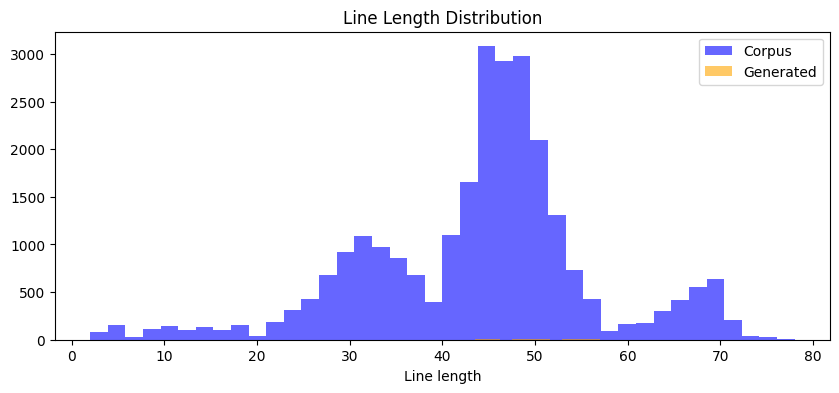

In [29]:
corpus_lines = [l for l in text.split("\n") if len(l) > 0]
corp_lengths = [len(l) for l in corpus_lines]
corp_rhymes = [rhyme_suffix(l) for l in corpus_lines if len(l.strip()) > 0]

print(f"Generated rhyme diversity: {len(set(gen_rhymes))}")
print(f"Corpus rhyme diversity: {len(set(corp_rhymes))}")

plt.figure(figsize=(10,4))
plt.hist(corp_lengths, bins=40, alpha=0.6, label="Corpus", color="blue")
plt.hist(lengths, bins=40, alpha=0.6, label="Generated", color="orange")
plt.xlabel("Line length"); plt.title("Line Length Distribution")
plt.legend(); plt.savefig("line_lengths.png", dpi=150); plt.show()

In [30]:
N_LAYERS = 3
model_small_real = PoetryGPT().to(device)
N_LAYERS = 6  # restore
print(f"6-layer model: 4.85M params")
print(f"3-layer model: {sum(p.numel() for p in model_small_real.parameters())/1e6:.2f}M params")

6-layer model: 4.85M params
3-layer model: 2.49M params


In [31]:
opt_s = AdamW(model_small_real.parameters(), lr=LR)
small_train_losses, small_steps = [], []
for step in range(5000):
    xb, yb = get_batch("train")
    _, loss = model_small_real(xb, yb)
    opt_s.zero_grad(); loss.backward(); opt_s.step()
    if step % 500 == 0:
        small_train_losses.append(loss.item())
        small_steps.append(step)
        print(f"Step {step} | loss={loss.item():.3f}")

Step 0 | loss=4.845
Step 500 | loss=2.298
Step 1000 | loss=1.964
Step 1500 | loss=1.753
Step 2000 | loss=1.555
Step 2500 | loss=1.445
Step 3000 | loss=1.360
Step 3500 | loss=1.273
Step 4000 | loss=1.182
Step 4500 | loss=1.086


In [32]:
BLOCK_SIZE = BLOCK_SIZE_SMALL
model_small_context = PoetryGPT().to(device)
BLOCK_SIZE = 256

opt_c = AdamW(model_small_context.parameters(), lr=LR)
context_train_losses, context_steps = [], []

for step in range(5000):
    xb, yb = get_batch("train", block_size=BLOCK_SIZE_SMALL, batch_size=BATCH_SIZE)
    _, loss = model_small_context(xb, yb)
    opt_c.zero_grad(); loss.backward(); opt_c.step()
    if step % 500 == 0:
        context_train_losses.append(loss.item())
        context_steps.append(step)
        print(f"Context128 Step {step} | loss={loss.item():.3f}")

Context128 Step 0 | loss=4.913
Context128 Step 500 | loss=2.067
Context128 Step 1000 | loss=1.703
Context128 Step 1500 | loss=1.551
Context128 Step 2000 | loss=1.420
Context128 Step 2500 | loss=1.246
Context128 Step 3000 | loss=1.079
Context128 Step 3500 | loss=0.966
Context128 Step 4000 | loss=0.859
Context128 Step 4500 | loss=0.767


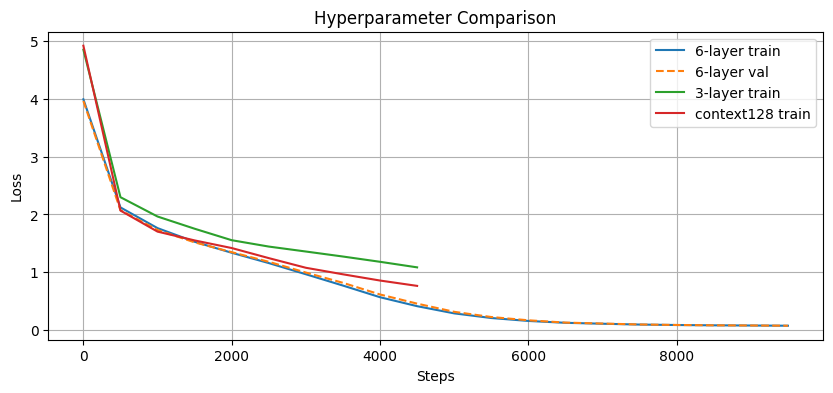

In [33]:
plt.figure(figsize=(10,4))
plt.plot(steps_log, train_losses, label="6-layer train")
plt.plot(steps_log, val_losses, label="6-layer val", linestyle="--")
plt.plot(small_steps, small_train_losses, label="3-layer train")
plt.plot(context_steps, context_train_losses, label="context128 train")
plt.xlabel("Steps"); plt.ylabel("Loss")
plt.title("Hyperparameter Comparison")
plt.legend(); plt.grid(True)
plt.savefig("model comparison.png", dpi=150); plt.show()

In [38]:
prompt_good = text[5000:5060]
print("Prompt:", repr(prompt_good))
print("\n=== GENERATED CONTINUATION ===")
print(generate(prompt=prompt_good, temperature=0.8, max_new_tokens=400))

Prompt: "ne d'une grâce farouche, avait à la\nfois quelque chose de di"

=== GENERATED CONTINUATION ===
ne d'une grâce farouche, avait à la
fois quelque chose de divin et de bestial ». Et Banville ajoute: «
Baudelaire faisait parfois asseoir Jeanne devant lui dans un grand
fauteuil; il la regardait avec amour et l'admirait longuement; il lui
disait des vers dans une langue qu'elle ne savait pas. Certes, c'est là
peut-être le meilleur moyen de causer avec une femme dont les paroles
détonneraient, sans doute, dans l'ardente symphonie que chante sa
beauté; mais


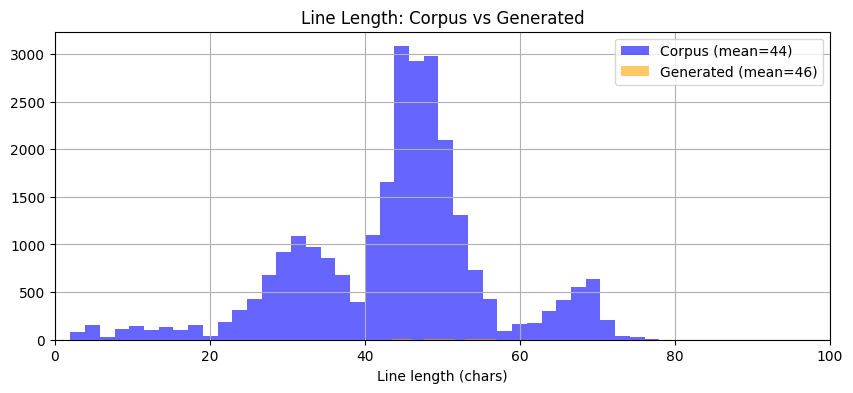

In [39]:
plt.figure(figsize=(10,4))
plt.hist(corp_lengths, bins=40, alpha=0.6, label=f"Corpus (mean={np.mean(corp_lengths):.0f})", color="blue")
plt.hist(lengths,      bins=40, alpha=0.6, label=f"Generated (mean={np.mean(lengths):.0f})", color="orange")
plt.xlabel("Line length (chars)"); plt.title("Line Length: Corpus vs Generated")
plt.xlim(0, 100); plt.legend(); plt.grid(True)
plt.savefig("line_lengths_fixed.png", dpi=150); plt.show()

In [40]:
final_train = train_losses[-1]
final_val = val_losses[-1]
final_bpc = final_val / math.log(2)

print(f"Final train loss : {final_train:.3f}")
print(f"Final val loss : {final_val:.3f}")
print(f"Final BPC : {final_bpc:.3f}")
print(f"Val/Train ratio : {final_val/final_train:.1f}x ← overfitting indicator")
print(f"Corpus size : {len(text)} chars (~{len(text)/1e6:.2f} MB)")
print(f"Vocab size : {vocab_size}")

torch.cuda.synchronize()
USE_FLASH_ATTENTION = True
start_time = time.time()
xb, yb = get_batch("train")
_, loss = model(xb, yb)
torch.cuda.synchronize()
flash_time = time.time() - start_time

torch.cuda.synchronize()
USE_FLASH_ATTENTION = False
start_time = time.time()
xb, yb = get_batch("train")
_, loss = model(xb, yb)
torch.cuda.synchronize()
mask_time = time.time() - start_time

USE_FLASH_ATTENTION = True

print(f"Flash attention forward time: {flash_time:.4f}s")
print(f"Masked attention forward time: {mask_time:.4f}s")

Final train loss : 0.079
Final val loss : 0.079
Final BPC : 0.113
Val/Train ratio : 1.0x ← overfitting indicator
Corpus size : 1200000 chars (~1.20 MB)
Vocab size : 107
Flash attention forward time: 0.0504s
Masked attention forward time: 0.0798s
